<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2001g.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

00000  var_x=7.765548e-06  vac_E=7.972627e-06  max_amp=4.942719e-02  patch_amp=4.455707e-02  kin_E=3.048837e-10  pot_E=-5.390582e-09  tot_E=-5.085699e-09
00010  var_x=4.119365e-06  vac_E=4.295847e-06  max_amp=2.057282e-02  patch_amp=2.022449e-02  kin_E=1.078764e-08  pot_E=-3.457376e-09  tot_E=7.330263e-09
00020  var_x=1.724842e-06  vac_E=1.857200e-06  max_amp=1.285050e-02  patch_amp=9.189128e-03  kin_E=1.251679e-08  pot_E=-3.149742e-09  tot_E=9.367048e-09
00030  var_x=2.578929e-06  vac_E=2.672121e-06  max_amp=2.626075e-02  patch_amp=2.357355e-02  kin_E=8.346523e-09  pot_E=-6.420827e-09  tot_E=1.925696e-09
00040  var_x=3.898551e-06  vac_E=3.962190e-06  max_amp=2.242906e-02  patch_amp=2.179891e-02  kin_E=6.399281e-09  pot_E=-7.426746e-09  tot_E=-1.027465e-09
00050  var_x=4.280925e-06  vac_E=4.325232e-06  max_amp=1.432669e-02  patch_amp=1.302962e-02  kin_E=6.910728e-09  pot_E=-7.048056e-09  tot_E=-1.373279e-10
00060  var_x=4.167909e-06  vac_E=4.199880e-06  max_amp=1.039949e-02  patch_amp=

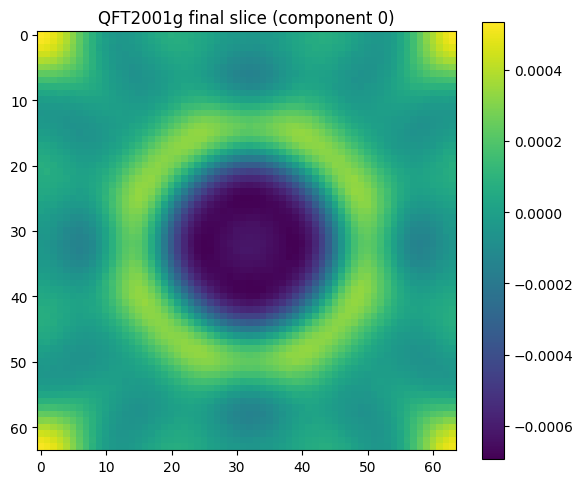

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# QFT2001g — Self-Focusing Test (lump frontier)
# ============================================================

L = 64
N_int = 100
steps = 2500  # longer to watch possible lump formation

lambda_c = 0.05   # stronger coupling
gamma    = 0.002  # very weak damping
alpha    = 3.0    # strong nonlinearity
noise_amp = 5e-5  # tiny symmetry-breaking noise

# ------------------------------------------------------------
# Initialization
# ------------------------------------------------------------
rng = np.random.default_rng(3001)

x = noise_amp * rng.normal(size=(L, L, L, N_int))

cx = cy = cz = L // 2
X, Y, Z = np.meshgrid(np.arange(L), np.arange(L), np.arange(L), indexing='ij')
R2 = (X - cx)**2 + (Y - cy)**2 + (Z - cz)**2
bump = np.exp(-R2 / (2 * (L/12)**2))

# Stronger initial bump to push into self-focusing regime
x += 0.05 * bump[..., None]

v = np.zeros_like(x)

# ------------------------------------------------------------
# Laplacian
# ------------------------------------------------------------
def laplacian(f):
    return (
        np.roll(f, 1, 0) + np.roll(f, -1, 0) +
        np.roll(f, 1, 1) + np.roll(f, -1, 1) +
        np.roll(f, 1, 2) + np.roll(f, -1, 2) -
        6.0 * f
    )

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
def diagnostics(step, x, v):
    var_x = np.var(x)
    vac_E = np.mean(x**2)
    max_amp = np.max(np.abs(x))
    patch = x[cx-2:cx+3, cy-2:cy+3, cz-2:cz+3]
    patch_amp = np.mean(np.abs(patch))
    kin_E = 0.5 * np.mean(v**2)
    # Note: for pot_E we use the same structure as before
    pot_E = 0.5 * lambda_c * np.mean(x * laplacian(x)) + 0.25 * alpha * np.mean(x**4)
    tot_E = kin_E + pot_E
    print(
        f"{step:05d}  var_x={var_x:.6e}  vac_E={vac_E:.6e}  "
        f"max_amp={max_amp:.6e}  patch_amp={patch_amp:.6e}  "
        f"kin_E={kin_E:.6e}  pot_E={pot_E:.6e}  tot_E={tot_E:.6e}"
    )

# ------------------------------------------------------------
# Main evolution loop
# ------------------------------------------------------------
for step in range(steps):
    lap = laplacian(x)
    force = lambda_c * lap - alpha * x**3
    v = (1 - gamma) * v + force
    x = x + v

    if step % 10 == 0:
        diagnostics(step, x, v)

# ------------------------------------------------------------
# Final slice plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.imshow(x[:, :, L//2, 0], cmap='viridis')
plt.colorbar()
plt.title("QFT2001g final slice (component 0)")
plt.tight_layout()
plt.show()
